importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

data collectiona nd processing


In [4]:
gold_data= pd.read_csv('/content/gld_price_data.csv')

In [6]:
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [7]:
 #print last five rows

In [8]:
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [9]:
#number of datapoint-- rows and columns

In [11]:
gold_data.shape


(2290, 6)

In [12]:
#getting some basic info about data

In [13]:
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [15]:
gold_data.isnull().sum() #missing values in each column

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [16]:
#getting statistical measures

In [17]:
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [18]:
#count->datapoints

find correlation between various columns in a dataset
1. positive correlation

In [23]:
correlation = gold_data.corr(numeric_only=True)

2. negative correlation
positive-> one increase, other increase , direct
negative -> inverse proportional  

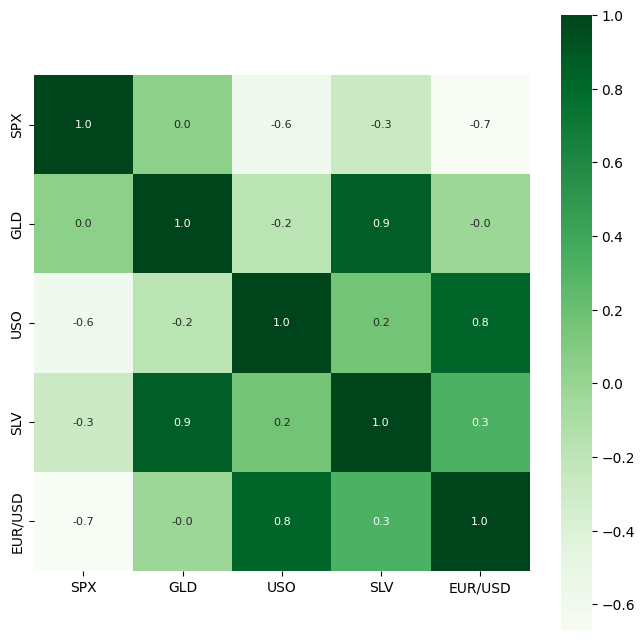

In [30]:
plt.figure(figsize=(8,8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Greens')
plt.show()


negative correlations have negative vakues, positive have posiitve

In [31]:
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


/tmp/ipython-input-485776295.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'],color='red')


<Axes: xlabel='GLD', ylabel='Density'>

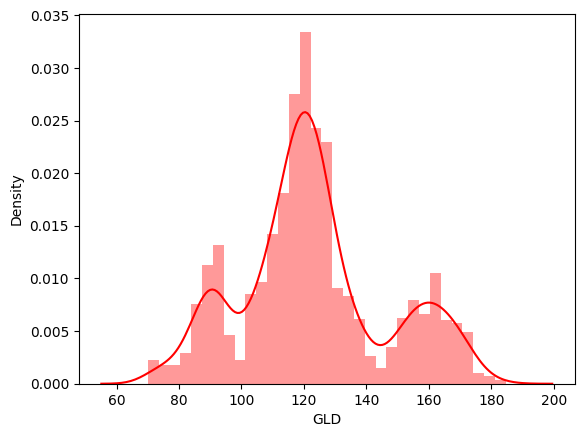

In [32]:
#checking the distribution of gold price
sns.distplot(gold_data['GLD'],color='red')

splitting features and target

In [33]:
X=gold_data.drop(['Date','GLD'],axis=1)
Y=gold_data['GLD']

In [34]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [35]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


splitting train test

In [36]:
X_train , X_test , Y_train, Y_test= train_test_split(X,Y, test_size= 0.2,random_state=2)

model training

use random forest RandomForestRegressor
how does it work
ensemble-> more than one model
decision trees

In [38]:
regressor= RandomForestRegressor(n_estimators=100)

In [39]:
regressor.fit(X_train, Y_train)

RandomForestRegressor()

MOdel evaluation

In [40]:
#prediction on test data
test_data_prediction = regressor.predict(X_test)

In [41]:
print(test_data_prediction)

[168.6696997   81.73570001 116.1346998  127.62080045 120.81830108
 154.77999754 150.3742985  126.12939985 117.50329884 126.15920043
 116.56660112 171.20800093 141.84069843 167.95649854 115.32089995
 117.64760046 140.23740279 170.55640115 159.39190288 160.5218987
 154.99769948 125.24550004 175.41719965 157.60100372 125.23100058
  93.8365998   77.87590037 120.35430024 119.0786992  167.43000032
  88.15510111 125.01520009  91.13010082 117.66170005 121.20649941
 135.98110113 115.58610119 114.96680051 148.14419983 107.25720114
 104.69330266  87.1651977  126.48230054 117.97810046 155.22839903
 119.61999995 108.43189965 107.86179823  93.1217006  127.06669824
  74.39750071 113.57209908 121.32370004 111.20979887 118.80979885
 120.38259977 159.6597996  168.05620162 146.85759673  85.86829843
  94.29150025  86.87439889  90.45719988 119.0762003  126.43650055
 127.55849993 169.29149932 122.26329919 117.42749928  98.39240048
 168.89450136 143.00719855 131.8872024  121.30580197 121.47439928
 119.806800

In [42]:
#R squared error
error_score = metrics.r2_score(Y_test, test_data_prediction)

In [43]:
print("R su=quared error:",error_score)

R su=quared error: 0.9894607703136494


Compare the actual values and predicted values in a plot

In [44]:
Y_test = list(Y_test)

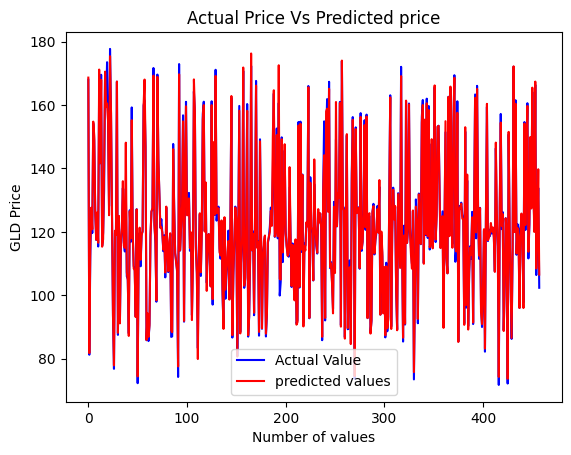

In [46]:
plt.plot(Y_test, color='blue',label='Actual Value')
plt.plot(test_data_prediction,color='red',label='predicted values')
plt.title('Actual Price Vs Predicted price')
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()



In [47]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.7 MB/s eta 0:00:00


In [48]:
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display

In [50]:
# Input widgets for features
spx = widgets.FloatText(description="SPX:", value=1000.0)
uso = widgets.FloatText(description="USO:", value=50.0)
slv = widgets.FloatText(description="SLV:", value=20.0)
eurusd = widgets.FloatText(description="EUR/USD:", value=1.2)

# Button + output area
predict_button = widgets.Button(description="Predict Gold Price")
output = widgets.Output()

# Function when button is clicked
def on_button_click(b):
    with output:
        output.clear_output()
        features = [[spx.value, uso.value, slv.value, eurusd.value]]
        prediction = regressor.predict(features)
        print(f"📈 Predicted Gold Price (GLD): {prediction[0]:.2f}")

# Link button to function
predict_button.on_click(on_button_click)

# Display everything
display(spx, uso, slv, eurusd, predict_button, output)

FloatText(value=1000.0, description='SPX:')

FloatText(value=50.0, description='USO:')

FloatText(value=20.0, description='SLV:')

FloatText(value=1.2, description='EUR/USD:')

Button(description='Predict Gold Price', style=ButtonStyle())

Output()